# M4 — Скільки тепла тримає квартира ❄️

Проєкт **«4331 година»** — клімат квартири та відключення світла, Харків.
Дані реальні: власна система Home Assistant, 16.03 – 15.09.2026.

Це **головний модуль проєкту**. M2 сказав, *коли* не було світла.
Тут ми питаємо, *що з цього виходить для людини в квартирі*:
скільки градусів за годину втрачає житло і за скільки годин стане холодно.

Число `k`, яке ми тут отримаємо, живить Excel-калькулятор (M9), дашборд і README.

## Питання

> **Скільки градусів за годину втрачає квартира, коли зникає світло?**

Підпитання:
1. Чому по самих відключеннях криву охолодження побудувати **не можна**?
2. Скільки дає метод «дві точки» на кожній із 5 подій?
3. Що каже про квартиру нічний спад температури за всі пів року?
4. Скільки годин від 22 °C до 18 °C при різній температурі надворі?
5. Чого це число ще **не** міряє?

Фізика одна на весь модуль — закон охолодження Ньютона:

$$T(t) = T_{вул} + (T_0 - T_{вул}) \cdot e^{-k t}$$

`k` (1/год) — коефіцієнт втрати тепла. `τ = 1/k` — теплова стала квартири:
за τ годин різниця з вулицею падає в e ≈ 2.72 раза.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import cooling

ROOT = pathlib.Path.cwd().parent
IMAGES = ROOT / "images"
RESULTS = ROOT / "results"

pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 55)

wide, events = cooling.load_clean(ROOT)
print(f"погодинна таблиця: {len(wide):,} годин, {wide.index.min()} … {wide.index.max()}")
print(f"відключень з M2:   {len(events)} · сумарно {events.hours.sum():.0f} год")

погодинна таблиця: 4,402 годин, 2026-03-16 08:00:00+00:00 … 2026-09-15 17:00:00+00:00
відключень з M2:   5 · сумарно 35 год


## Дані

Нічого не довантажуємо — беремо готові таблиці M1 і журнал подій M2.

| Таблиця | Що це | Роль у M4 |
|---|---|---|
| `data/clean/hours_wide.csv` | година × (кімнати, вулиця) | `T0`, `T_end`, `T_вул`, нічний спад |
| `data/clean/readings_hourly.csv` | прапорець `stuck` з M1 | застряглі години глушимо в `NaN` |
| `results/m2_outages.csv` | 5 подій, 35 год без світла | межі кожної події |

Застряглий датчик — не свідок: якщо M1 позначив годину як `stuck`, ми не беремо її
ні в метод A, ні в метод B (у житловій кімнаті таких 169 год, на кухні — 23).

In [2]:
# Що ми маємо по кожній події: температура надворі й тривалість
ev = events[["event_id", "start_kyiv", "hours"]].copy()
ev["t_out_c"] = [
    wide.loc[(wide.index >= e.start_utc) & (wide.index < e.end_utc), "out_temp"].mean()
    for e in events.itertuples()
]
ev.round(1)

,event_id,start_kyiv,hours,t_out_c
0,OUT-001,2026-03-18 03:00:00+02:00,6.0,2.2
1,OUT-002,2026-06-13 11:00:00+03:00,8.0,22.0
2,OUT-003,2026-07-11 12:00:00+03:00,5.0,20.2
3,OUT-004,2026-07-12 11:00:00+03:00,7.0,20.5
4,OUT-005,2026-07-25 11:00:00+03:00,9.0,23.9


Усі п'ять подій — теплі: навіть найхолодніша (18 березня) мала надворі **+2 °C**,
решта — липень і червень, +20…+24 °C. Це вже підказує, що літні блекаути
охолодження майже не покажуть.

## Чому тут лише дві точки

Усі кімнатні датчики живляться **від розетки**. Немає світла — немає показів.
Тому всередині відключення в даних **порожньо**: є тільки останній показ *до*
(`T0`) і перший *після* (`T_end`).

Отже `curve_fit` по самій події підганяв би криву **по двох точках** — а це не крива,
це одне число. Формула згортається до:

$$k = -\frac{\ln\!\big((T_{end} - T_{вул}) / (T_0 - T_{вул})\big)}{годин}$$

In [3]:
# Доказ: беремо найдовше відключення і дивимось, що записано всередині
e = events.loc[events.hours.idxmax()]
win = wide.loc[(wide.index >= e.start_utc - pd.Timedelta(hours=1))
               & (wide.index <= e.end_utc), ["bedroom_temp", "kitchen_temp",
                                             "printernya_temp", "out_temp"]]
print(f"{e.event_id}: {e.start_kyiv} → {e.hours:.0f} год")
win.round(2)

OUT-005: 2026-07-25 11:00:00+03:00 → 9 год


,bedroom_temp,kitchen_temp,printernya_temp,out_temp
ts,,,,
2026-07-25 07:00:00+00:00,25.86,26.80,29.03,22.2
2026-07-25 08:00:00+00:00,NaN,NaN,NaN,22.6
2026-07-25 09:00:00+00:00,NaN,NaN,NaN,23.3
2026-07-25 10:00:00+00:00,NaN,NaN,NaN,24.0
2026-07-25 11:00:00+00:00,NaN,NaN,NaN,24.4
2026-07-25 12:00:00+00:00,NaN,NaN,NaN,24.9
2026-07-25 13:00:00+00:00,NaN,NaN,NaN,24.5
2026-07-25 14:00:00+00:00,NaN,NaN,NaN,24.5
2026-07-25 15:00:00+00:00,NaN,NaN,NaN,23.7


Рівно те, про що йшлося: перший рядок (за годину до) і останній (після відновлення)
заповнені, а **всі години самого відключення — `NaN`** по кімнатах. Вулиця пише
завжди: погода приходить з Open-Meteo, а не з розетки.

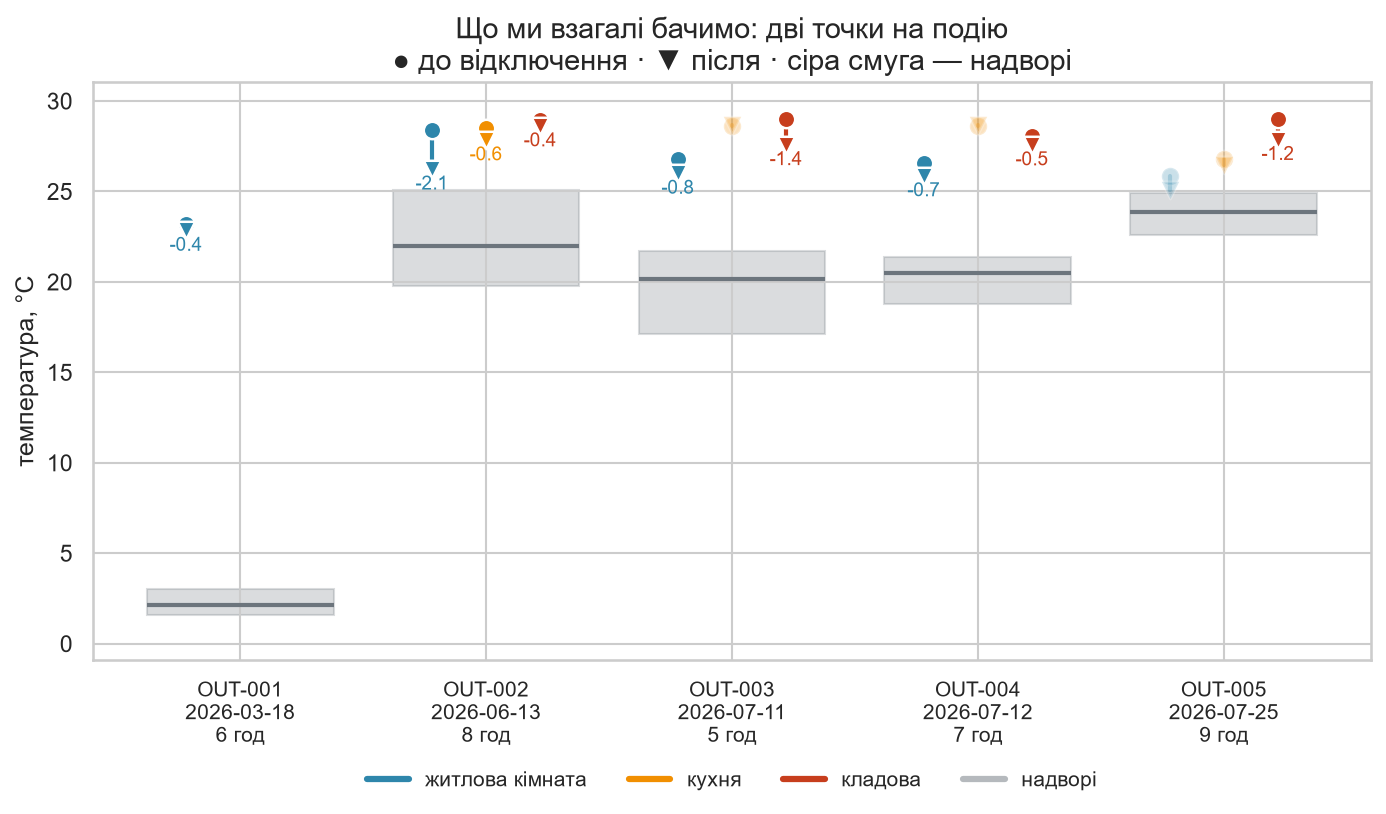

In [4]:
display(Image(filename=str(IMAGES / "m4_event_two_point.png")))

Кожне відключення — дві виміряні точки на кімнату: ● до і ▼ після. Сіра смуга —
температура надворі за ті самі години. Видно головну проблему: у липні смуга
майже дістає до точок, тобто «різниця з вулицею» дуже мала.

## Метод A — дві точки на кожне відключення

Рахуємо `k` для всіх 5 подій × 3 кімнати = 15 рядків і **чесно позначаємо**,
які з них нікуди не годяться. Рядок відкидаємо, якщо:

| Правило | Чому |
|---|---|
| показ далі ніж за 3 год від події | датчик у той період узагалі не працював |
| \|`T0` − `T_вул`\| < 3 °C | ділимо майже на нуль → `k` розлітається |
| різниця змінила знак | кімната стала холоднішою за вулицю — Ньютон тут не працює |
| `k` ≤ 0 | кімната за подію не охолола, а нагрілась |

In [5]:
tab = cooling.event_two_point_table(wide, events)
view = tab[["event_id", "room_ua", "hours", "t0_c", "t_end_c", "t_out_c",
            "delta_t0_c", "drop_c", "k_per_h", "used", "reason"]].round(2)
view["k_per_h"] = tab["k_per_h"].round(4)     # k мале — двох знаків мало
view

,event_id,room_ua,hours,t0_c,t_end_c,t_out_c,delta_t0_c,drop_c,k_per_h,used,reason
0,OUT-001,житлова кімната,6.0,23.21,22.84,2.15,21.06,-0.36,0.0029,True,
1,OUT-001,кухня,6.0,NaN,25.59,2.15,NaN,NaN,NaN,False,датчик ще не працював — немає показу біля події
2,OUT-001,кладова,6.0,NaN,24.54,2.15,NaN,NaN,NaN,False,датчик ще не працював — немає показу біля події
3,OUT-002,житлова кімната,8.0,28.37,26.23,22.00,6.37,-2.14,0.0511,True,
4,OUT-002,кухня,8.0,28.49,27.84,22.00,6.49,-0.65,0.0131,True,
5,OUT-002,кладова,8.0,28.97,28.62,22.00,6.97,-0.35,0.0065,True,
6,OUT-003,житлова кімната,5.0,26.80,26.00,20.18,6.62,-0.80,0.0257,True,
7,OUT-003,кухня,5.0,28.65,28.66,20.18,8.47,0.02,NaN,False,найближчий показ аж за 375 год від події
8,OUT-003,кладова,5.0,29.00,27.58,20.18,8.82,-1.42,0.0351,True,
9,OUT-004,житлова кімната,7.0,26.59,25.86,20.50,6.09,-0.73,0.0182,True,


З 15 рядків вижило **9**. Дві типові причини відмови:
кухня й кладова просто ще не існували в даних на момент першої події (18 березня),
а 25 липня надворі було +23.9 °C — різниця з кімнатою лише 2 °C, це ділення на шум.

In [6]:
summary_a = (tab[tab.used]
             .groupby("room_ua")["k_per_h"]
             .agg(подій="size", медіана="median", мін="min", макс="max")
             .round(4))
summary_a["τ, год (медіана)"] = (1 / summary_a["медіана"]).round(0)
summary_a

,подій,медіана,мін,макс,"τ, год (медіана)"
room_ua,,,,,
житлова кімната,4,0.0219,0.0029,0.0511,46.0
кладова,4,0.0188,0.0065,0.0351,53.0
кухня,1,0.0131,0.0131,0.0131,76.0


Розкид усередині однієї кімнати — **до 17 разів** (житлова: 0.0029 … 0.0511).
Це не три різні квартири, це три різні умови. І найвище `k` дає не найхолодніша
подія, а найтепліша: 13 червня разом зі світлом вимкнулися сервер, NAS і принтер,
і кімната охолола не через стіни, а тому що **перестали гріти прилади**.

## Метод B — нічний спад за всі пів року

Якщо всередині відключень даних немає, візьмемо їх звідти, де вони є:
з **4402 звичайних годин**. Квартира ж охолоняє не тільки без світла.

Для кожного кроку «година → наступна година» рахуємо:

$$\Delta T_{in} = a - k \cdot (T_{in} - T_{out})$$

і робимо звичайний МНК (`statsmodels`). Нахил із мінусом — і є `k`.

Два обмеження вибірки:
* **лише ночі 23:00–06:00** (київський час) — вдень сонце й техніка гріють квартиру
  саме тоді, коли надворі тепло, і підгонка ламається;
* **обидві години кроку** мають бути в нічному вікні й мати дані.

In [7]:
fits = cooling.fit_all_rooms(wide, night_only=True)
pd.DataFrame([{
    "кімната": cooling.ROOM_LABELS_UA[r],
    "n точок": f["n_points"],
    "k, 1/год": round(f["k"], 5),
    "CI 95 % низ": round(f["ci_low"], 5),
    "CI 95 % верх": round(f["ci_high"], 5),
    "τ, год": round(f["tau_h"], 0),
    "R²": round(f["r2"], 4),
    "p": round(f["p_value"], 4),
} for r, f in fits.items()])

,кімната,n точок,"k, 1/год",CI 95 % низ,CI 95 % верх,"τ, год",R²,p
0,житлова кімната,1203,0.00348,-0.00229,0.00925,287.0,0.0012,0.2369
1,кухня,777,0.00221,-0.00135,0.00578,452.0,0.0019,0.2235
2,кладова,1114,0.00305,0.00182,0.00429,327.0,0.0207,0.0000


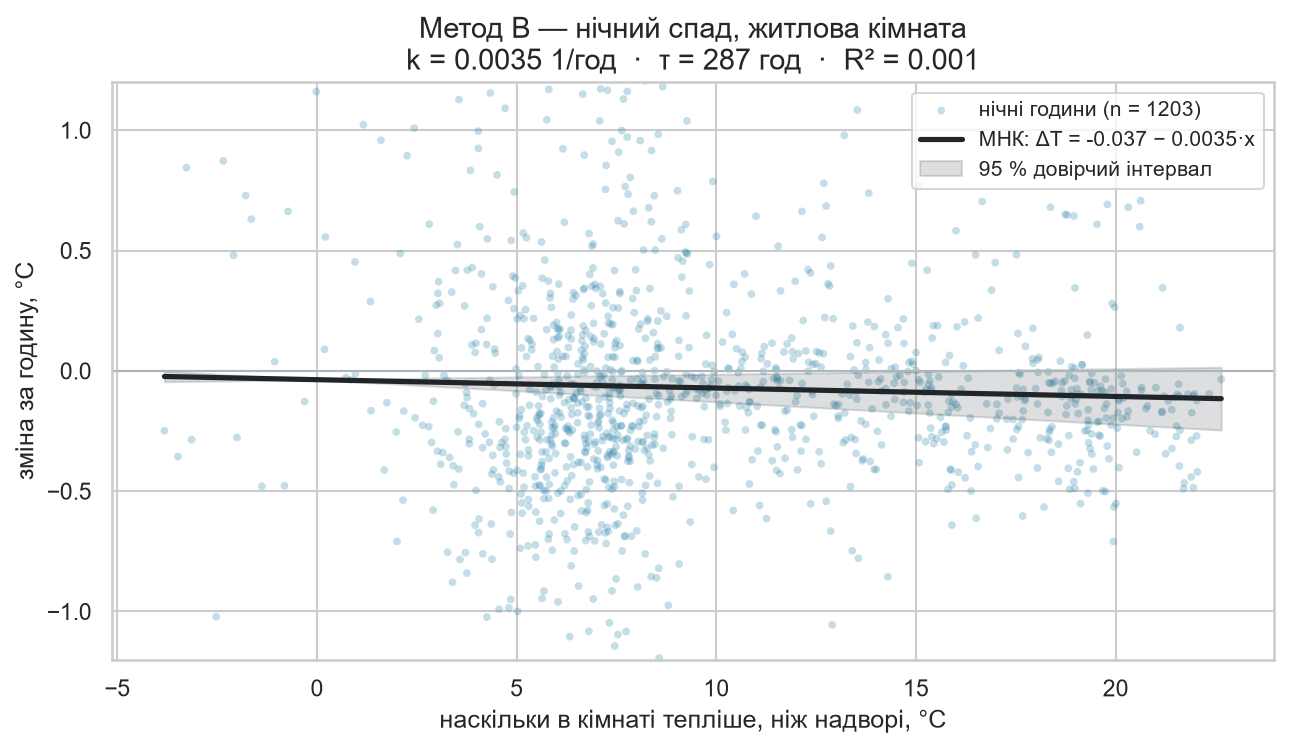

In [8]:
display(Image(filename=str(IMAGES / "m4_night_decay.png")))

Хмара точок і майже горизонтальна пряма: чим тепліше в кімнаті проти вулиці, тим
швидше вона холоне — але **ледь-ледь**. `R² = 0.001`: різниця з вулицею пояснює
частку відсотка нічних змін температури. Решта — сусіди, техніка, теплова маса стін.

⚠️ Чесно: у житловій кімнаті й на кухні довірчий інтервал **перетинає нуль**
(p ≈ 0.22). Значущий результат лише в кладовій — вона без вікна, її режим
найспокійніший.

In [9]:
# Перевірка на чутливість: та сама регресія по ВСІХ годинах, не лише вночі
fits_all = cooling.fit_all_rooms(wide, night_only=False)
pd.DataFrame([{
    "кімната": cooling.ROOM_LABELS_UA[r],
    "k (ночі)": round(fits[r]["k"], 5),
    "k (всі години)": round(fits_all[r]["k"], 5),
    "n (ночі)": fits[r]["n_points"],
    "n (всі)": fits_all[r]["n_points"],
} for r in cooling.ROOMS])

,кімната,k (ночі),k (всі години),n (ночі),n (всі)
0,житлова кімната,0.00348,-0.00740,1203,4136
1,кухня,0.00221,-0.00132,777,2645
2,кладова,0.00305,0.00080,1114,3785


Ось навіщо були потрібні ночі: по всіх годинах житлова кімната й кухня дають
**від'ємне `k`** — нібито квартира тим швидше нагрівається, чим вона тепліша за
вулицю. Фізичної нісенітниці тут немає, є класичний конфаундер: удень сонце
світить у вікно і техніка працює саме тоді, коли надворі спекотно.
Ніч це прибирає.

## Порівняння двох методів

| | Метод A — дві точки | Метод B — нічний спад |
|---|---|---|
| Джерело | 5 реальних блекаутів | 4402 години звичайного життя |
| Точок на оцінку | 2 | ~1200 (ночі) |
| Плюс | це справжнє відключення | вузький інтервал, багато даних |
| Мінус | влітку `T0 − T_вул` мале → шум | міряє квартиру «з сусідами», а не блекаут |

In [10]:
cmp = pd.DataFrame([{
    "кімната": cooling.ROOM_LABELS_UA[r],
    "A: медіана k": round(tab[tab.used & (tab.room == r)]["k_per_h"].median(), 4),
    "A: подій": int(tab[tab.used & (tab.room == r)].shape[0]),
    "B: k": round(fits[r]["k"], 4),
    "B: τ, год": round(fits[r]["tau_h"], 0),
    "A/B, разів": round(tab[tab.used & (tab.room == r)]["k_per_h"].median() / fits[r]["k"], 1),
} for r in cooling.ROOMS])
cmp

,кімната,A: медіана k,A: подій,B: k,"B: τ, год","A/B, разів"
0,житлова кімната,0.0219,4,0.0035,287.0,6.3
1,кухня,0.0131,1,0.0022,452.0,5.9
2,кладова,0.0188,4,0.0031,327.0,6.2


Метод A дає в 6–7 разів більше `k`, ніж метод B. Але є одна подія, де вони
**сходяться**: OUT-001, 18 березня, надворі +2 °C — єдиний випадок із великою
різницею (21 °C). Там метод A дав `k = 0.0029`, метод B по ночах — `0.0035`.

Тобто чим краще обумовлена подія, тим ближче вона до «нічного» числа, а літні
події просто міряють щось інше: вимкнення техніки й добовий хід температури.
Тому в контракт результатів іде **`k` методу B**.

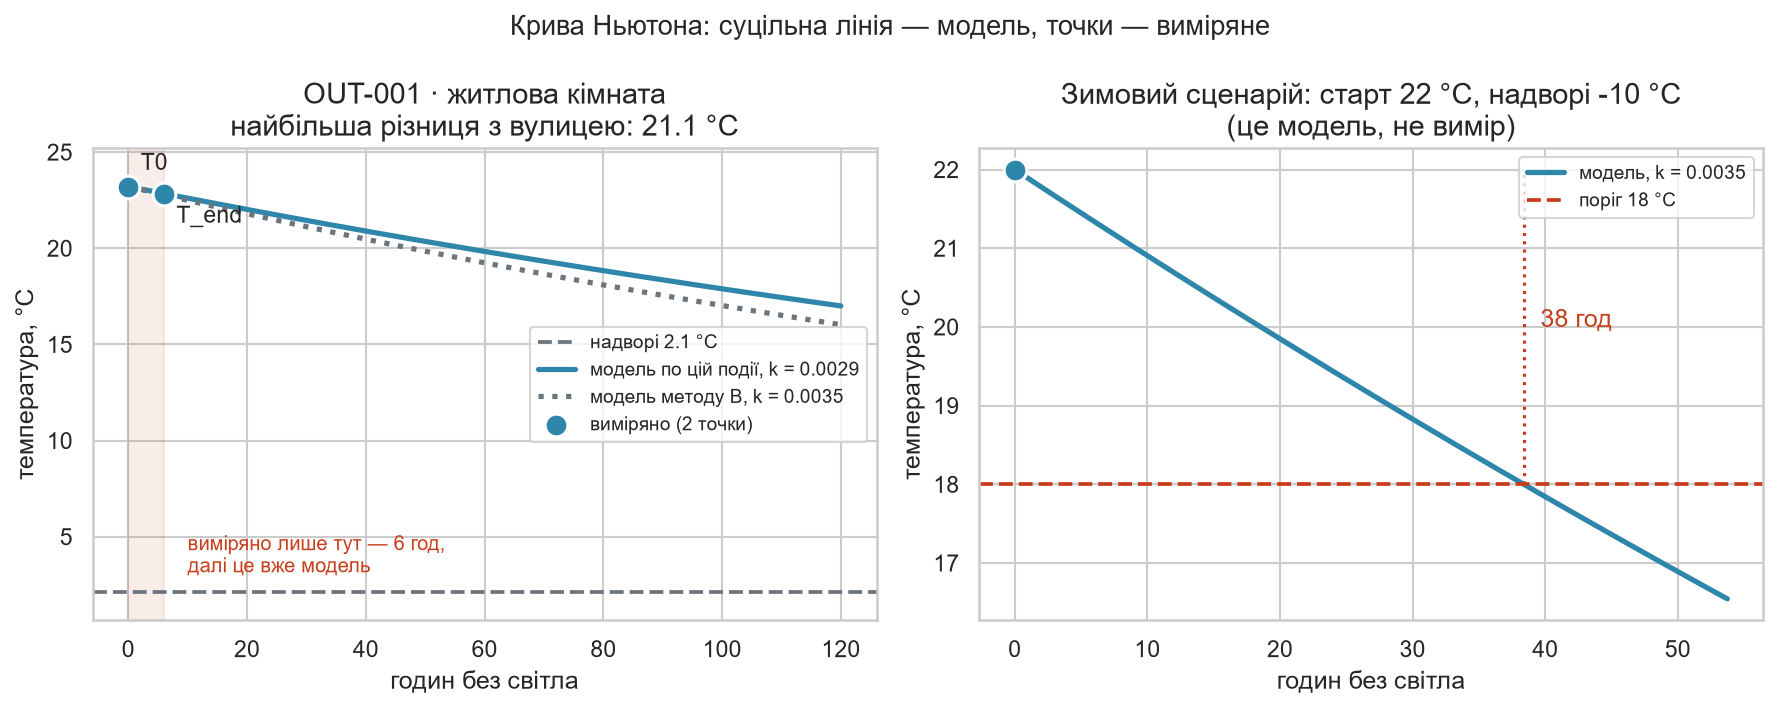

In [11]:
display(Image(filename=str(IMAGES / "m4_newton_curve.png")))

Зліва — демонстрація на найкраще обумовленій події: рожева смуга (6 год) — це
**все, що виміряно**, далі суцільна й пунктирна лінії вже домальовані моделлю.
Справа — зимовий сценарій: старт 22 °C, надворі −10 °C. Точка одна — старт;
уся крива — модель.

## Скільки годин до 18 °C

Практична відповідь усього проєкту. Формула — та сама, що піде в Excel (M9):

$$годин = \frac{\ln\!\big((T_0 - T_{вул}) / (поріг - T_{вул})\big)}{k}$$

Excel україномовний, тож у калькуляторі це `=LN((B2-B3)/(B4-B3))/B5`
з крапкою з комою як роздільником аргументів.

In [12]:
htab = pd.read_csv(RESULTS / "m4_hours_table.csv")
(htab[["t_out_c", "hours_bedroom", "hours_kitchen", "hours_printernya",
       "rate_c_per_h_bedroom"]]
 .rename(columns={"t_out_c": "надворі, °C", "hours_bedroom": "житлова, год",
                  "hours_kitchen": "кухня, год", "hours_printernya": "кладова, год",
                  "rate_c_per_h_bedroom": "°C/год на старті (житлова)"})
 .round(2))

,"надворі, °C","житлова, год","кухня, год","кладова, год",°C/год на старті (житлова)
0,-20.0,28.77,45.19,32.77,0.15
1,-15.0,32.89,51.66,37.46,0.13
2,-10.0,38.38,60.29,43.72,0.11
3,-5.0,46.09,72.40,52.50,0.09
4,0.0,57.68,90.60,65.71,0.08
5,5.0,77.11,121.12,87.84,0.06
6,10.0,116.56,183.07,132.77,0.04


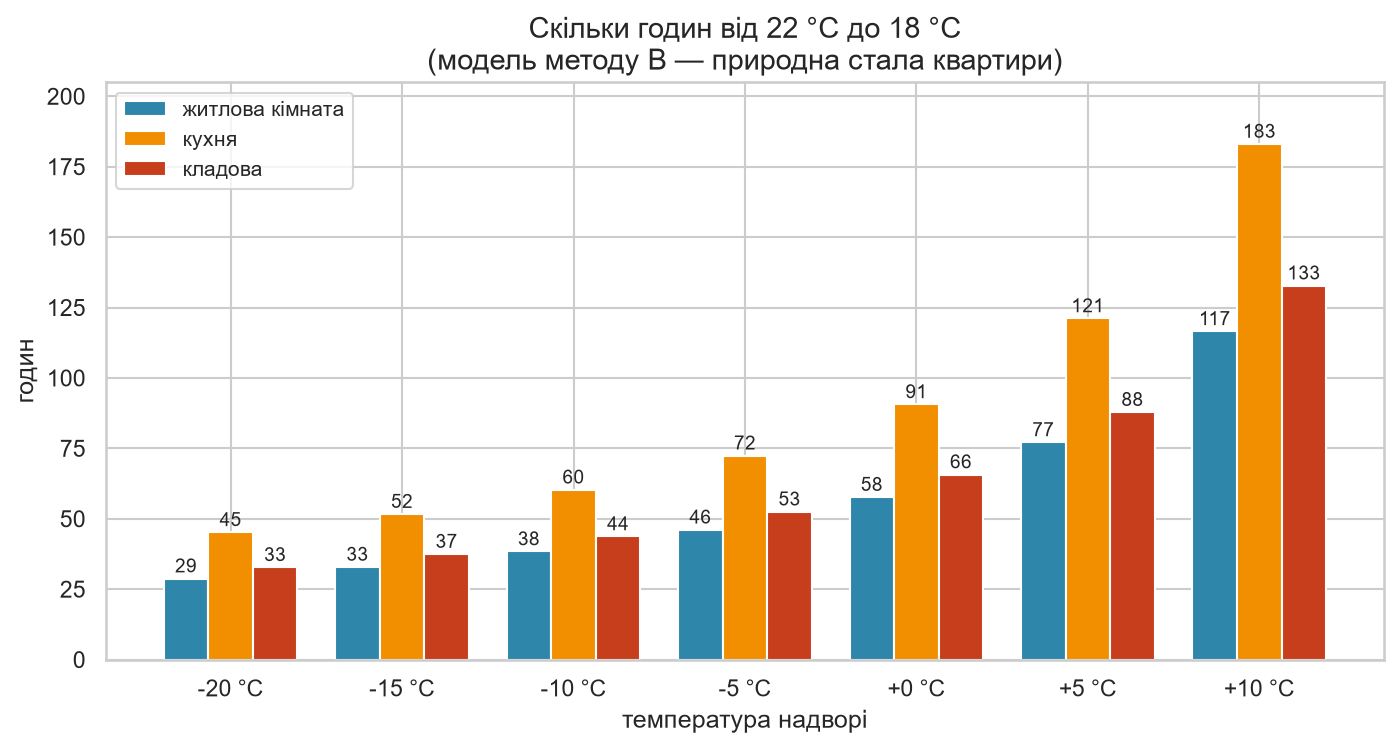

In [13]:
display(Image(filename=str(IMAGES / "m4_hours_table.png")))

Навіть при −20 °C надворі житлова кімната йде від 22 °C до 18 °C **~29 годин**.
При −10 °C — **38 годин**, тобто втрата ≈ **0.11 °C/год** у першу годину.
Це означає просту річ: жодне з наших відключень (найдовше — 9 год) не здатне
вистудити квартиру до дискомфорту. Кухня тримає тепло ще довше — але там і
покриття датчика лише 68 %, тож до її числа довіри менше.

## Обмеження

1. **Усередині відключення вимірів немає.** Метод A принципово дає одне число на
   подію, а не криву. Це властивість розеткового живлення, а не наш недогляд.
2. **Усі 5 подій — літні.** Надворі було +2…+24 °C, у 2 випадках різниця з кімнатою
   < 3 °C, і ці рядки довелось відкинути. Справжній зимовий блекаут перерахуємо,
   коли будуть зимові дані.
3. **`k` методу B — це не «порожня коробка на морозі».** Це природна теплова стала
   квартири **разом** із теплом сусідів крізь стіни й стояками опалення. Квартира
   не стоїть окремо: її з усіх боків гріють інші опалювані квартири.
4. **Статистична значущість слабка.** У житловій кімнаті CI перетинає нуль
   (p ≈ 0.24), R² ≈ 0.001. Плюс залишки автокорельовані (ρ ≈ 0.2), тож звичайний
   OLS-інтервал радше оптимістичний. Число беремо як **оцінку порядку**, не як точку.
5. **Кухня — 68 % покриття** датчика, тому її `k` найшумніший; кладову гріє
   3D-принтер і NAS (модуль M5), тож її «природний спад» теж не зовсім природний.
6. **Техніка вимикається разом зі світлом.** У методі A це частина сигналу — і саме
   вона, а не стіни, робить літнє `k` таким високим.

## Висновки

* **Крива по події неможлива:** під час блекауту розеткові датчики мовчать, є лише
  2 точки — до і після. З 15 рядків «подія × кімната» придатними виявились **9**.
* **Метод B (ночі, 6 місяців, n = 1203):** `k` житлової кімнати = **0.0035 1/год**,
  CI 95 % [−0.0023; 0.0092], τ ≈ **287 год**. Кухня 0.0022, кладова 0.0031
  (єдина статистично значуща, p < 0.001).
* **Метод A (медіани):** житлова **0.0219**, кухня 0.0131, кладова 0.0188 — у 6–7
  разів більше. Але найкраще обумовлена подія (18.03, різниця 21 °C) дала **0.0029**,
  тобто практично число методу B. Літні події міряють вимкнення техніки, а не стіни.
* **Практика:** від 22 °C до 18 °C квартирі треба **29 год** при −20 °C, **38 год**
  при −10 °C і **58 год** при 0 °C. Швидкість падіння на старті при −10 °C —
  **0.11 °C/год**.
* **Головний висновок для мешканця:** за пів року найдовше відключення тривало
  9 годин — це близько **1 °C** втрати. Квартиру рятує не утеплення, а сусіди:
  вона стоїть усередині опалюваного будинку.

## Як сказати на співбесіді за 30 секунд

> У квартирі 5 відключень за пів року, і головна пастка в тому, що під час
> відключення датчики знеструмлені — усередині події даних нема взагалі, є лише
> точка до і точка після. Тому «підгонка кривої Ньютона» по події — це насправді
> дві точки й одне `k`. Я зробила два методи й порівняла їх: по подіях (метод A) і
> регресію нічного спаду температури за всі пів року, 1200 точок (метод B).
> Метод A дав розкид у 17 разів, бо влітку різниця з вулицею падала до 2 °C — я
> ці рядки відкинула із явною причиною, а не «підчистила». Метод B дав
> `k ≈ 0.0035 1/год`, тобто теплова стала квартири ≈ 287 годин: від 22 °C до 18 °C
> при −10 °C надворі — близько 38 годин. Практичний висновок: 9-годинний блекаут
> коштує квартирі приблизно один градус. І я окремо кажу, чого це число не міряє:
> це квартира разом із теплими сусідами, а не порожня коробка на морозі —
> зимові дані перерахую, коли вони з'являться.

In [14]:
# Повний прогін модуля — записує всі файли результатів
m = cooling.run_all(ROOT)
for f in ["results/m4_cooling.json", "results/m4_events.csv", "results/m4_hours_table.csv",
          "images/m4_event_two_point.png", "images/m4_night_decay.png",
          "images/m4_newton_curve.png", "images/m4_hours_table.png"]:
    p = ROOT / f
    print(f"{'OK ' if p.exists() else 'НЕМА'} {f:38s} {p.stat().st_size:>8,} b")
print()
print(f"k_bedroom = {m['k_bedroom']:.5f} 1/год · τ = {m['tau_bedroom_h']:.0f} год · "
      f"до 18 °C при −10 °C: {m['hours_to_18_from_22_at_minus10']:.0f} год")

OK  results/m4_cooling.json                   3,531 b
OK  results/m4_events.csv                     3,423 b
OK  results/m4_hours_table.csv                  520 b
OK  images/m4_event_two_point.png            72,378 b
OK  images/m4_night_decay.png               170,620 b
OK  images/m4_newton_curve.png              138,637 b
OK  images/m4_hours_table.png                62,823 b

k_bedroom = 0.00348 1/год · τ = 287 год · до 18 °C при −10 °C: 38 год
